In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers

import pandas as pd
import numpy as np
import re
import torch

Mounted at /content/drive


In [2]:
# PHASE 1: Data Loading

import pandas as pd

path = "/content/drive/MyDrive/fake_job_postings.csv"

df = pd.read_csv(path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [3]:
# PHASE 2: Data Preprocessing

import re

df = df.fillna("")

df["text"] = df["title"] + " " + df["description"] + " " + df["requirements"]

def clean_text(text):
    text = re.sub(r'[^a-zA-Z ]', '', str(text))
    text = text.lower()
    return text

df["text"] = df["text"].apply(clean_text)

df = df[["text", "fraudulent"]]

df.head()

,text,fraudulent
0,marketing intern food a fastgrowing james bear...,0
1,customer service cloud video production organ...,0
2,commissioning machinery assistant cma our clie...,0
3,account executive washington dc the company e...,0
4,bill review manager job title itemization revi...,0


In [4]:
print(df["fraudulent"].value_counts())
print(df["text"].iloc[0][:200])

fraudulent
0    17014
1      866
Name: count, dtype: int64
marketing intern food a fastgrowing james beard awardwinning online food community and crowdsourced and curated recipe hub is currently interviewing full and parttime unpaid interns to work in a small


Baseline Model Phase

In [5]:
# PHASE 3: Train-Test Split

from sklearn.model_selection import train_test_split

X = df["text"]
y = df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 14304
Testing samples: 3576


In [6]:
# PHASE 4: TF-IDF Feature Extraction

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (14304, 5000)
TF-IDF testing shape: (3576, 5000)


In [7]:
# PHASE 5: Logistic Regression Baseline Model

from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_tfidf, y_train)

print("Baseline model training completed")

Baseline model training completed


In [8]:
# PHASE 6: Baseline Model Evaluation

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

baseline_predictions = baseline_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, baseline_predictions)
precision = precision_score(y_test, baseline_predictions)
recall = recall_score(y_test, baseline_predictions)
f1 = f1_score(y_test, baseline_predictions)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Accuracy: 0.9662
Precision: 0.9815
Recall: 0.3064
F1 Score: 0.467


In [9]:
print(classification_report(y_test, baseline_predictions))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3403
           1       0.98      0.31      0.47       173

    accuracy                           0.97      3576
   macro avg       0.97      0.65      0.72      3576
weighted avg       0.97      0.97      0.96      3576



In [10]:
print(confusion_matrix(y_test, baseline_predictions))

[[3402    1]
 [ 120   53]]


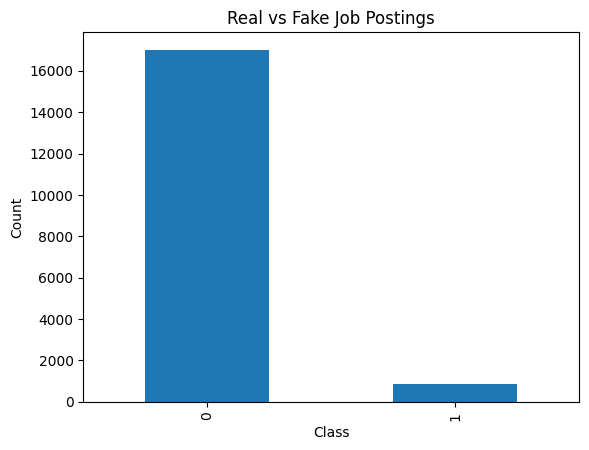

In [11]:
# PHASE 7: Class Distribution

import matplotlib.pyplot as plt

df["fraudulent"].value_counts().plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Real vs Fake Job Postings")

plt.show()